In [47]:
import networkx as nx
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
graph = nx.read_gexf(BASE_DIR / "data" / "processed" / "world_trade_network_petrol_2024.gexf")

### 1) Degree analysis:

In [48]:
# 1.1) Nodes degree (considering the weight and the in and out degree):

# In order to visualize these metrics better, we shall display them as a Pandas DataFrame: 

metrics = []
for node in graph.nodes():
    metrics.append({
        'Country': node,

        # Diplomacy (number of associates -> Without considering weights): 
        'Num_Exports': graph.out_degree(node),
        'Num_Imports': graph.in_degree(node),

        # Economy (volume of trades -> considering weights):
        'Amount_Exports': graph.out_degree(node, weight='weight'),
        'Amount_Imports': graph.in_degree(node, weight='weight')
    })

df_metrics = pd.DataFrame(metrics).sort_values(by='Amount_Exports', ascending=False)
df_metrics.head(5)

,Country,Num_Exports,Num_Imports,Amount_Exports,Amount_Imports
32,SAU,28,2,1.868739e+08,7.337000e+04
112,RUS,14,1,1.241959e+08,7.246048e+03
27,USA,72,41,1.220353e+08,1.696897e+08
0,ARE,27,8,1.144340e+08,4.718464e+05
2,CAN,22,32,1.085083e+08,1.542743e+07


In [49]:
# 1.2) Average degrees:
average_degrees = df_metrics[['Num_Exports', 'Num_Imports', 'Amount_Exports', 'Amount_Imports']].mean()
average_degrees

Num_Exports       7.323699e+00
Num_Imports       7.323699e+00
Amount_Exports    7.562504e+06
Amount_Imports    7.562504e+06
dtype: float64

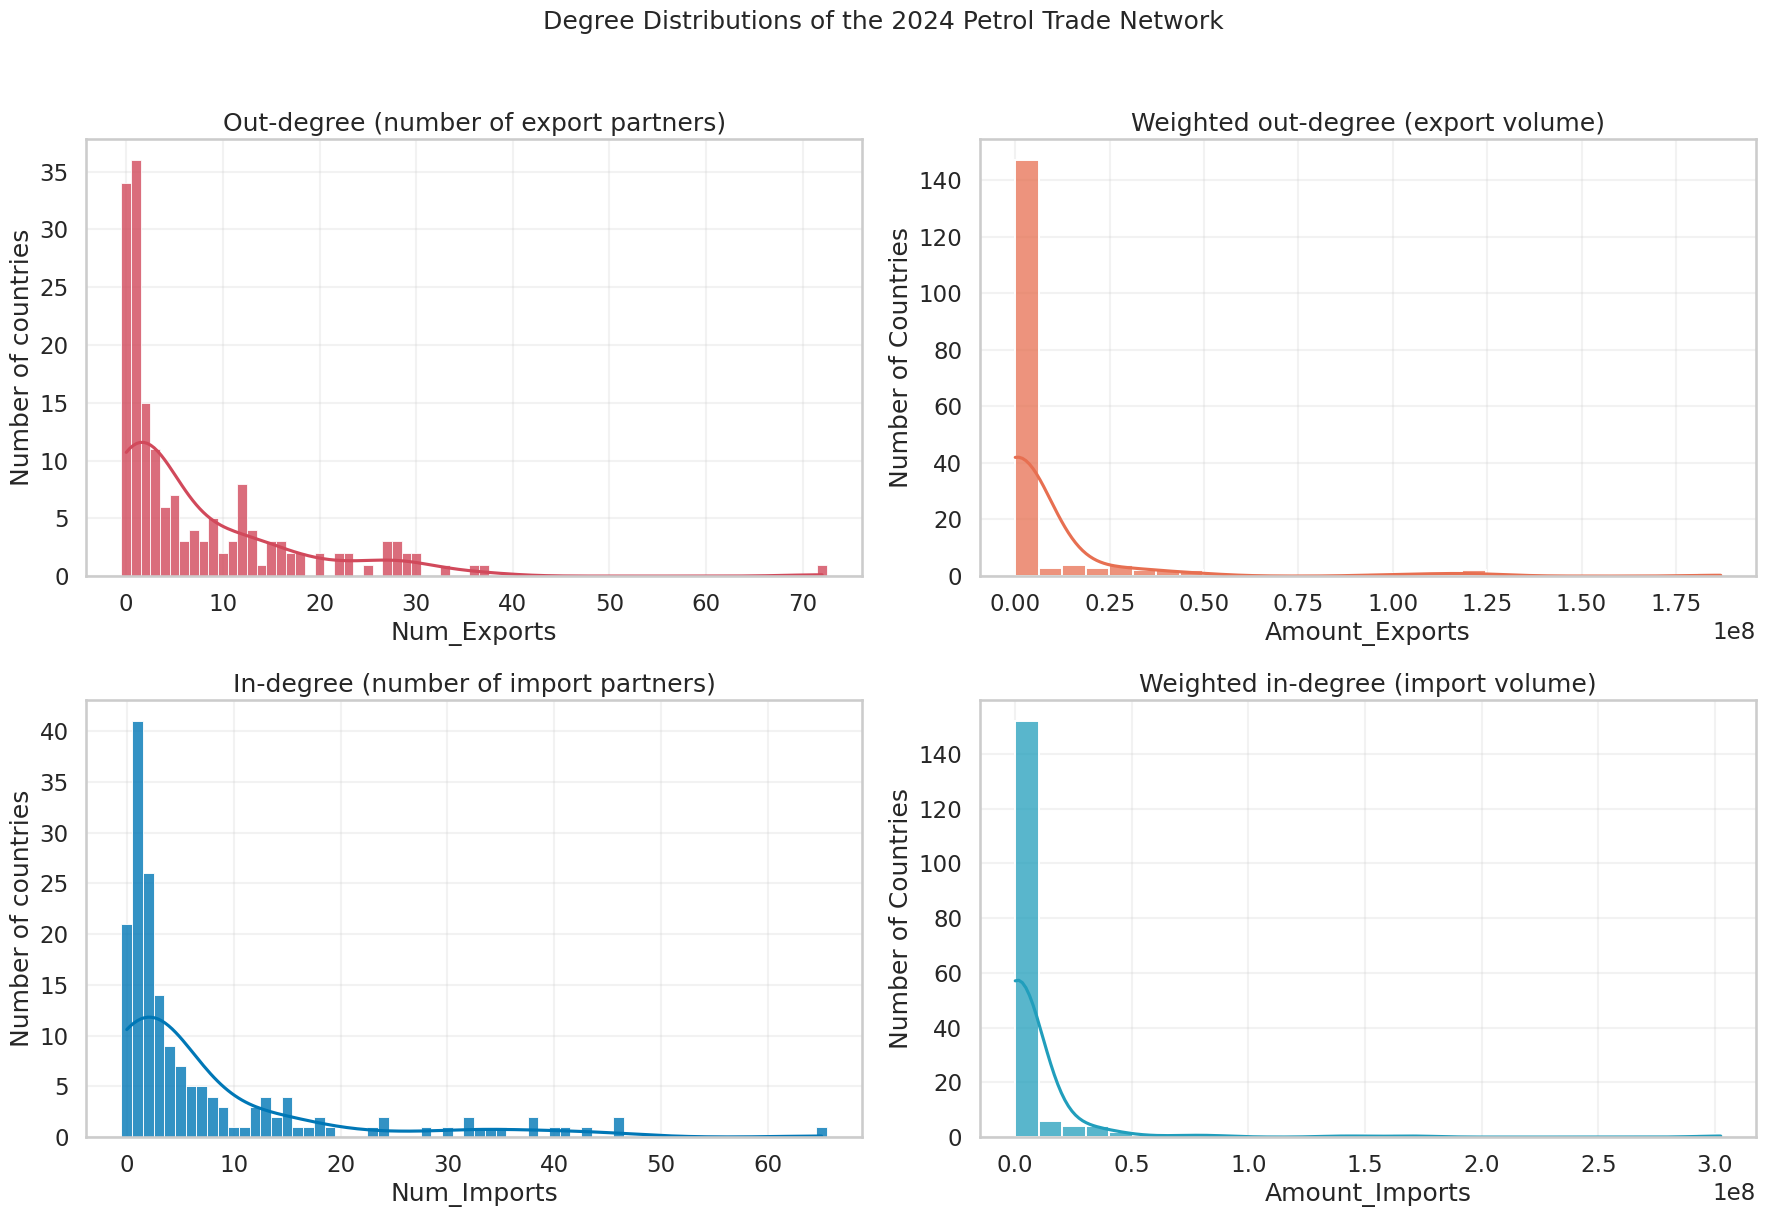

In [52]:
# 1.3) Degree distribution:
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# Declare the maximum of number of exports and imports in order to specify a top
# when assigning the bins in the respective histograms:
max_exports = int(df_metrics['Num_Exports'].max())
max_imports = int(df_metrics['Num_Imports'].max())

# Number of exports:
sns.histplot(
    data=df_metrics,
    x='Num_Exports',
    bins=range(0, max_exports + 2),
    discrete=True,
    kde=True,
    color='#d1495b',
    alpha=0.8,
    ax=ax[0, 0]
 )
ax[0, 0].set_title('Out-degree (number of export partners)')
ax[0, 0].set_xlabel('Num_Exports')
ax[0, 0].set_ylabel('Number of countries')

# Number of imports:
sns.histplot(
    data=df_metrics,
    x='Num_Imports',
    bins=range(0, max_imports + 2),
    discrete=True,
    kde=True,
    color='#0077b6',
    alpha=0.8,
    ax=ax[1, 0]
 )
ax[1, 0].set_title('In-degree (number of import partners)')
ax[1, 0].set_xlabel('Num_Imports')
ax[1, 0].set_ylabel('Number of countries')

# Amount of exports:
sns.histplot(
    data=df_metrics,
    x='Amount_Exports',
    bins=30,
    kde=True,
    color='#e76f51',
    alpha=0.75,
    ax=ax[0, 1]
 )
ax[0, 1].set_title('Weighted out-degree (export volume)')
ax[0, 1].set_xlabel('Amount_Exports')
ax[0, 1].set_ylabel('Number of Countries')
ax[0, 1].ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

# Amount of imports:
sns.histplot(
    data=df_metrics,
    x='Amount_Imports',
    bins=30,
    kde=True,
    color='#219ebc',
    alpha=0.75,
    ax=ax[1, 1]
 )
ax[1, 1].set_title('Weighted in-degree (import volume)')
ax[1, 1].set_xlabel('Amount_Imports')
ax[1, 1].set_ylabel('Number of Countries')
ax[1, 1].ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

for axis in ax.flat:
    axis.grid(alpha=0.25)

fig.suptitle('Degree Distributions of the 2024 Petrol Trade Network', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 2) Betweenness:

In [57]:
# 2.1) Betweenness analysis: 

# Here we must consider something important - the betweenness centrality calculates the number 
# of minimum paths in an specific node. The thing is that this minimum path is calculated according to
# the weights, so that an edge which presents a huge flow of goods would be considered as a "path with huge cost", 
# but we know that in economy it means the opposite. Thus, we will be using the inverse of the weight as the distance: 

for u, v, d in graph.edges(data=True):
    # We add a minuscule value (1e-6) to avoid divisions by zero in case any weight is 0:
    graph[u][v]['distance'] = 1 / (d['weight'] + 1e-6)

# Calculate the betweennes centrality considering the "distance" as the weight:
betweenness = nx.betweenness_centrality(graph, weight='distance', normalized=True)

# Save it in the metrics DataFrame: 
df_metrics['Betweenness'] = df_metrics['Country'].map(betweenness)

df_metrics.sort_values(by='Betweenness', ascending=False).head(5)

,Country,Num_Exports,Num_Imports,Amount_Exports,Amount_Imports,Betweenness
27,USA,72,41,1.220353e+08,1.696897e+08,0.486944
0,ARE,27,8,1.144340e+08,4.718464e+05,0.245648
23,AUS,18,17,6.437415e+06,5.202191e+06,0.241330
9,MYS,17,28,3.406534e+07,1.458343e+07,0.224398
49,QAT,16,23,2.114437e+07,1.772118e+06,0.182137


### 3) Motifs:

In [60]:
# 3.1) Local clustering coefficient: 
local_clustering = nx.clustering(graph)

df_metrics['Local_Clustering'] = df_metrics['Country'].map(local_clustering)
df_metrics.sort_values(by='Local_Clustering', ascending=False).head(7)

,Country,Num_Exports,Num_Imports,Amount_Exports,Amount_Imports,Betweenness,Local_Clustering
134,CYP,1,2,34591.822,29.504,0.0,1.000000
165,CUB,1,1,0.024,7.785,0.0,1.000000
82,ABW,1,1,0.081,21.744,0.0,1.000000
160,BGD,0,2,0.000,38910.592,0.0,1.000000
87,LUX,2,4,0.078,11.222,0.0,0.892857
120,LBR,3,2,114061.892,21.727,0.0,0.750000
25,CMR,9,0,2698320.188,0.000,0.0,0.680556


In [61]:
# 3.2) Global clustering coefficient (transitivity):
transitivity = nx.transitivity(graph)
transitivity 

0.24935962120624078

### 4) Reciprocity:

In [ ]:
# 4.1) Reciprocity: 

### 5) Geodetic paths and position:

In [ ]:
# 5.1) Diameter: 

In [ ]:
# 5.2) Excentricity:

In [ ]:
# 5.3) Average geodesic path:

### 6) Components: 

In [ ]:
# 6.1) Connected components analysis: 